# Sprint 5 - Análisis Exploratorio de Datos (Sesiones)

En el presente caso de estudio se busca integrar y aplicar los conocimientos desarrollados previamente en programación, manipulación de datos y visualización, orientándolos hacia la construcción de uno de los procesos fundamentales dentro de la ciencia de datos: el **Análisis Exploratorio de Datos** (comúnmente conocido como EDA por sus siglas en inglés). Este tipo de análisis constituye una de las primeras etapas dentro de cualquier proyecto analítico o modelado predictivo, ya que permite comprender en profundidad la naturaleza de los datos antes de desarrollar modelos estadísticos o algoritmos de aprendizaje automático.

El propósito principal del **EDA** es examinar, resumir e interpretar la información disponible con el fin de identificar patrones, tendencias, anomalías, relaciones entre variables y posibles problemas de calidad en los datos. Más allá de simplemente observar tablas o calcular métricas básicas, el **EDA** busca generar una comprensión integral del comportamiento de las variables y de los fenómenos representados en el conjunto de datos. Esta etapa resulta esencial para formular hipótesis, detectar inconsistencias, definir estrategias de modelado y orientar adecuadamente la toma de decisiones basada en información.

En el contexto profesional, este análisis representa una habilidad indispensable para cualquier científico o analista de datos, ya que una comprensión insuficiente de los datos puede conducir a interpretaciones incorrectas, conclusiones erróneas o modelos poco confiables. Por esta razón, el **EDA** no debe entenderse únicamente como una etapa técnica, sino también como un proceso analítico e investigativo que combina herramientas estadísticas, pensamiento crítico y capacidad de interpretación.

Para desarrollar este tipo de análisis, tradicionalmente se emplean tres grandes herramientas complementarias que aportan mecanismos distintos para explorar y comprender la información desde diferentes perspectivas:

* **Estadística descriptiva**: corresponde al conjunto de técnicas orientadas al resumen y representación de datos mediante medidas estadísticas, con el objetivo es describir las características principales de una variable o conjunto de variables. Estas herramientas permiten por tanto obtener una visión inicial del comportamiento general de los datos y constituyen el punto de partida de cualquier **EDA**.
* **Estadística inferencial**: corresponde al área de la estadística enfocada en la formulación y validación de hipótesis a partir de la información disponible. A diferencia de la estadística descriptiva, que únicamente resume datos observados, la inferencia estadística busca extraer conclusiones más generales sobre estos datos, así como las relaciones y comportamientos subyacentes. Dentro de un **EDA**, este tipo de herramientas puede ayudar a evaluar asociaciones entre variables, diferencias entre grupos existentes y posibles patrones estadísticamente relevantes en el contexto.
* **Visualización de datos**: representa una de las herramientas más poderosas dentro del análisis exploratorio, ya que permite interpretar información compleja de manera intuitiva mediante gráficos y representaciones visuales equivalentes, haciendo posible identificar tendencias, valores atípicos, agrupamientos y relaciones que muchas veces no son evidentes únicamente con estadísticas numéricas. En consecuencia, la visualización complementa y fortalece tanto la estadística descriptiva como la inferencial, facilitando además la comunicación efectiva de hallazgos.

Durante el desarrollo de este caso de estudio, vamos a aplicar estos conocimientos con librerías ya conocidas como **Pandas** y **Matplotlib**, e incorporaremos otra comunmente usada en **EDA** llamada **Scipy**. Con esto, seremos capaces de construir un flujo básico de trabajo analítico similar al utilizado en proyectos reales de ciencia de datos y analítica de negocios, permitiéndote desarrollar no solamente habilidades técnicas relacionadas con programación y estadística aplicada, sino también capacidades analíticas fundamentales para interpretar información, formular preguntas relevantes y generar conocimiento útil a partir de los datos disponibles.

## Entendimiento del contexto

El Banco Mundial es un organismo multinacional cuyo propósito es el brindar asistencia económica y financiera a sus estados asociados. Entre los servicios que ofrece se encuentra la de generar y publicar diversos indicadores macroeconómicos, sociales, demográficos y ambientales que permiten estudiar y contrastar la situación multidimensional entre países a través de los años. Si es de tu interés, puedes acceder a todo su catálogo de información en este [repositorio](https://data.worldbank.org/).

Un dato importante para que tengas en cuenta es que a nivel mundial se reconocen oficialmente poco más de 200 estados, de los cuales algunos proveen de información al Banco Mundial (estados miembro de la entidad) y otros no lo hacen. La entidad, si le es posible, estima mediante modelos econométricos algunos de estos indicadores faltantes, aunque en muchos casos ha preferido dejar en blanco estos datos a fin de garantizar la integridad original de la información. 

Visto este escenario, el Banco Mundial te ha contratado para que realices un análisis respecto al comportamiento de la Variación del Producto Interno Bruto (PIB) entre los años 2000 y 2023. En concreto, esta entidad quiere que le asistas contestando las siguientes preguntas clave para una mayor comprensión de esta métrica:

* ¿Cuál ha sido el comportamiento de este indicador a partir del cambio de siglo?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión o reducción del PIB en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

## Entendimiento de los datos

Como punto de partida, vale que importes las librerías que vas a utilizar, incluyendo el módulo **Stats** de **Scipy** que contiene funciones y métodos para análisis estadístico de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st # st es el pseudónimo utilizado comunmente para el módulo stats

Vamos a importar además una librería llamada **Warnings** con el siguiente código:

```py
import warnings
warnings.filterwarnings("ignore")
```

Hacer esto evitará que surjan mensajes de advertencia o informativos que dificulten la lectura de nuestro notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

Carga ahora los datos de los archivos [**cat_codpais3.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/cat_codpais3.csv), [**wb_ahorro.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_ahorro.csv), [**wb_crecim_pib.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_crecimpib.csv), [**wb_crecimpob.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_crecimpob.csv) y [**wb_poburbana.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_poburbana.csv). Estos datos son los que te ha compartido el Banco Mundial para que bases tu análisis a partir de allí.

In [3]:
# Cargar cat_codpais3
cat_pais = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/cat_codpais3.csv")

# Cargar wb_ahorro
df_ahorro = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_ahorro.csv")

# Cargar wb_crecimpib
df_pib = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_crecimpib.csv")

# Cargar wb_crecimpob
df_poblacion = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_crecimpob.csv")

# Cargar wb_poburbana
df_urbana = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/wb_poburbana.csv")

Las 5 tablas contienen información asociada a indicadores macroeconómicos por país de acuerdo al siguiente detalle:

* **cat_codpais3**: [264 filas, 2 columnas] Catálogo que contiene el nombre de cada país y sus siglas *Alpha-3* de acuerdo a la normativa ISO.
* **wb_ahorro**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje promedio de ahorro que mantienen los habitantes como porcentaje de su ingreso. 
* **wb_crecimpib**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación del PIB. 
* **wb_crecimpob**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación de la población.
* **wb_poburbana**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje de la población que reside en áreas urbanas.

Con el objetivo de una exploración de datos y diagnóstico más eficientes, crea una función que te permita mirar: 

* La estructura general del dataset.
* Una muestra aleatoria de 5 filas en la que se presenten solamente las primeras 6 columnas del dataset.
* Un conteo de los duplicados existentes.

In [4]:
def fun_diagnostico (df):
    print("ESTRUCTURA GENERAL DE LA TABLA:")
    print(df.info())
    print()
    print("MUESTRA DE LOS DATOS: ")
    print(df.sample(5).iloc[:,:6])
    print()
    print(f"FILAS DUPLICADAS: {df.duplicated().sum()}")

Aplica la función creada en cada uno de los datasets para conocerlos en mayor detalle.

In [5]:
# Explorar cat_pais
fun_diagnostico(cat_pais)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   country_code  214 non-null    str  
 1   country_name  214 non-null    str  
dtypes: str(2)
memory usage: 6.2 KB
None

MUESTRA DE LOS DATOS: 
    country_code country_name
127          MMR      Myanmar
120          MDG   Madagascar
134          MWI       Malawi
0            ABW        Aruba
68           GBR  Reino Unido

FILAS DUPLICADAS: 0


In [6]:
# Explorar df_ahorro
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    str    
 1   2000          161 non-null    float64
 2   2001          160 non-null    float64
 3   2002          167 non-null    float64
 4   2003          169 non-null    float64
 5   2004          169 non-null    float64
 6   2005          187 non-null    float64
 7   2006          190 non-null    float64
 8   2007          195 non-null    float64
 9   2008          196 non-null    float64
 10  2009          198 non-null    float64
 11  2010          200 non-null    float64
 12  2011          201 non-null    float64
 13  2012          204 non-null    float64
 14  2013          204 non-null    float64
 15  2014          206 non-null    float64
 16  2015          207 non-null    float64
 17  2016          205 non-null    float64
 18  2017     

In [7]:
# Explorar df_pib
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    str    
 1   2000          246 non-null    float64
 2   2001          247 non-null    float64
 3   2002          247 non-null    float64
 4   2003          251 non-null    float64
 5   2004          251 non-null    float64
 6   2005          251 non-null    float64
 7   2006          251 non-null    float64
 8   2007          252 non-null    float64
 9   2008          252 non-null    float64
 10  2009          255 non-null    float64
 11  2010          255 non-null    float64
 12  2011          255 non-null    float64
 13  2012          255 non-null    float64
 14  2013          255 non-null    float64
 15  2014          256 non-null    float64
 16  2015          256 non-null    float64
 17  2016          255 non-null    float64
 18  2017     

In [8]:
# Explorar df_poblacion
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    str    
 1   2000          264 non-null    float64
 2   2001          264 non-null    float64
 3   2002          264 non-null    float64
 4   2003          264 non-null    float64
 5   2004          264 non-null    float64
 6   2005          264 non-null    float64
 7   2006          264 non-null    float64
 8   2007          264 non-null    float64
 9   2008          264 non-null    float64
 10  2009          264 non-null    float64
 11  2010          264 non-null    float64
 12  2011          264 non-null    float64
 13  2012          264 non-null    float64
 14  2013          264 non-null    float64
 15  2014          264 non-null    float64
 16  2015          264 non-null    float64
 17  2016          264 non-null    float64
 18  2017     

In [9]:
# Explorar df_urbana
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    str    
 1   2000          262 non-null    float64
 2   2001          262 non-null    float64
 3   2002          262 non-null    float64
 4   2003          262 non-null    float64
 5   2004          262 non-null    float64
 6   2005          262 non-null    float64
 7   2006          262 non-null    float64
 8   2007          262 non-null    float64
 9   2008          262 non-null    float64
 10  2009          262 non-null    float64
 11  2010          262 non-null    float64
 12  2011          262 non-null    float64
 13  2012          262 non-null    float64
 14  2013          262 non-null    float64
 15  2014          262 non-null    float64
 16  2015          262 non-null    float64
 17  2016          262 non-null    float64
 18  2017     

Excluyendo a la tabla con el catálogo de países, podrás notar que el resto de datasets tiene una estructura particular en la que cada año está representado por una columna distinta. Esto puede resultar complejo y para comprobarlo hagamos un experimento: filtra los datos de variación del PIB de Estados Unidos (USA) de los años 2013 a 2019, y guarda el resultado en una variable `pib_usa`.

In [10]:
pib_usa = df_pib.query("`Country Code` == 'USA'").loc[:,"2013":"2019"]
print(pib_usa)

        2013     2014     2015      2016      2017      2018      2019
251  2.11783  2.52382  2.94555  1.819451  2.457622  2.966505  2.467038


Intenta ahora graficar estos datos con el método `plot` como usualmente lo has venido haciendo. No te preocupes por aspectos de formato pues solamente es un ejemplo ilustrativo.

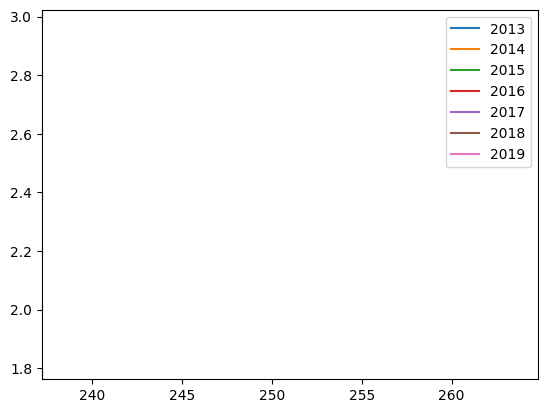

In [11]:
pib_usa.plot()
plt.show()

En cuanto a estos resultados notemos dos puntos importantes: 

* Por una parte, el filtrado no es tan natural como usualmente lo hacemos. De hecho resultaría imposible en este punto responder esta pregunta usando el método `query` para filtrar los años solicitados. 
* Además, no es posible graficar de forma directa y sencilla con el método `plot`. Requeriríamos de una transformación adicional de la información para que funcione adecuadamente. 

Esto se explica porque el dataset que muestra información de variación en el PIB es **ANCHO**. Un dataset ancho es aquel en que cada fila representa a una única entidad (en este caso un país) que no se repite en otras filas. Su utilidad radica en que esta presentación de datos es fácil de interpretar por usuarios "no analíticos", justamente porque se puede acceder a la totalidad información de cada entidad de forma rápida y directa en un solo registro.

Sin embargo, para usuarios "analíticos" como nosotros esta presentación no es adecuada, pues nosotros queremos tablas **LARGAS**. En una tabla larga cada fila representa una observación (o lo que es lo mismo un dato) con sus diferentes variables y particularidades, facilitando en consecuencia la manipulación y visualización de información.

Visto todo esto, define tu plan de acción para preparar estos datos.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

La tabla con el catalogo de paises no presenta novedades por lo que se debe mantener en su estado actual. En cuanto al resto es necesario llevar a cabo el siguiente procesamiento:

| # | Acción |
| ---- | ---- |
| 1 | Es necesario transformar su presentación para que sean tablas *largas* que permitan su uso analítico. |
| 2 | Los nombres de las columnas deben ajustarse a formato *snake_case*. |
| 3 | Hemos evidenciado que existen valores perdidos en los diferentes datasets, sin embargo dado el contexto puede que estos respondan a diferentes situación dependiendo del país al cual se corresponden (i.e países sin ningún valor o países con un pequeño número de casos ausentes). Se debe por tanto tomar una decisión sobre como tratarlos una vez que sea posible filtrar esta información fácilmente. |

Una vez realizados estos pasos, conviene unir todos los datasets en una única tabla consolidada a fin de no depender de diferentes fuentes durante el análisis.

## Preparación de datos

Vamos a empezar con la tabla que tiene información de la variación del PIB. Transforma la presentación *ancha* de esta tabla a una de tipo *larga*, aplicando el método `melt` de tal forma que se genere un dataset de 3 columnas: Country Code, year y value.

In [12]:
# Transformar a presentacion larga con metodo melt
df_pib = df_pib.melt(
    id_vars = "Country Code",  
    var_name = "year", 
    value_name = "value"
)
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  6360 non-null   str    
 1   year          6360 non-null   str    
 2   value         6051 non-null   float64
dtypes: float64(1), str(2)
memory usage: 193.4 KB
None

MUESTRA DE LOS DATOS: 
     Country Code  year     value
3330          MDA  2012 -0.589734
789           WSM  2002  5.651959
3380          QAT  2012  4.730012
5511          SLV  2020 -7.893101
5124          GRC  2019  1.879490

FILAS DUPLICADAS: 0


Se debe señalar que igualmente se puede utilizar también la función `wide_to_long` tal y como se muestra a continuación:

```py
# Transformar a presentacion larga con funcion wide_to_long
df_pib = pd.wide_to_long(
    df_pib,
    stubnames = "",
    i = "Country Code",
    j = "year" 
).reset_index()
df_pib = df_pib.rename(columns = {"":"value"})
```

Te sugiero que investigues sobre su funcionalidad en la documentación de **Pandas**.

Ajusta los nombres de las columnas para que estos sigan el formato *snake_case*.

In [13]:
df_pib.columns = [x.lower().replace(" ","_") for x in df_pib.columns]
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6360 non-null   str    
 1   year          6360 non-null   str    
 2   value         6051 non-null   float64
dtypes: float64(1), str(2)
memory usage: 193.4 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year     value
2852          RUS  2010  4.500000
5756          PRE  2021  3.154260
3529          GIB  2013       NaN
5071          CEB  2019  3.908522
904           IND  2003  7.860381

FILAS DUPLICADAS: 0


Ya podemos estudiar los valores perdidos con esta tabla *larga*. Identifica diferentes tipologías de países en función de cuántos valores ausentes tengan.

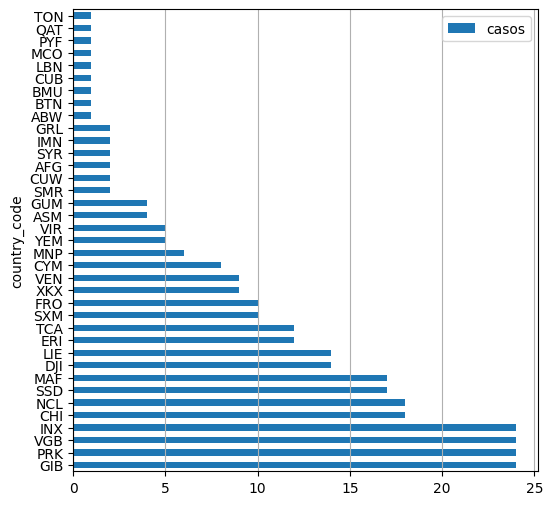

In [14]:
# Obtener casos perdidos por país
casos_perdidos = (
    df_pib[df_pib["value"].isna()]
    .groupby("country_code")
    .agg(casos = ("country_code","count"))
    .sort_values(by = "casos", ascending = False)
)
casos_perdidos.plot(
    kind = "barh",
    figsize = [6,6]
)
plt.grid(axis = "x")
plt.show()

Visto esto, podríamos dividir a los países en 2 grupos en base a sus valores ausentes y aplicando de forma simplificada la Ley de Pareto:

* Aquellos que tienen 5 o menos menos años con valores perdidos.
* El resto que posee más del 5 años con valores perdidos.

Para el último caso que correspondería a los países con pocos o ningún dato relevante, elimina todos estos registros pues su información está limitada pudiendo distorsionar los análisis.

In [15]:
paises_eliminar = list(casos_perdidos.query('casos > 5').index)
df_pib = df_pib[~df_pib["country_code"].isin(paises_eliminar)]
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
Index: 5928 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   str    
 1   year          5928 non-null   str    
 2   value         5889 non-null   float64
dtypes: float64(1), str(2)
memory usage: 227.2 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year      value
6241          MAC  2023  80.534216
2951          CEB  2011   3.514209
567           CHE  2002  -0.073217
3385          SAU  2012   5.408916
4564          DOM  2017   4.666705

FILAS DUPLICADAS: 0


Para el primer caso, en donde existen muchos datos relevantes, aplica una imputación por el valor mediano de dicho país considerando que esto no alterará significativamente los resultados de los análisis.

In [16]:
# Obtener la mediana por pais
med_por_pais = (
    df_pib
    .groupby("country_code")
    .agg(med = ("value","median"))
    .reset_index()
)

# Incluir de forma temporal la mediana en el dataset
df_pib = df_pib.merge(
    med_por_pais,
    on = "country_code"
)

# Imputar la mediana en los casos perdidos correspondientes
df_pib["value"] = df_pib["value"].fillna(df_pib["med"])

# Quitar columna de mediana 
df_pib = df_pib.drop(columns = "med")
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   str    
 1   year          5928 non-null   str    
 2   value         5928 non-null   float64
dtypes: float64(1), str(2)
memory usage: 181.0 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year     value
676           PRT  2002  0.770924
1407          OSS  2005  4.941936
5032          HPC  2020  0.236251
551           DZA  2002  5.400000
1320          GRL  2005  4.987492

FILAS DUPLICADAS: 0


Concluye ejecutando los siguientes procedimientos de limpieza adicionales:

* Cambiar el tipo de variable de year a entero.
* Cambia el nombre de la columna value a algo más coherente con el contexto como *var_pib*.

In [17]:
# Cambiar el tipo de variable de year
df_pib["year"] = df_pib["year"].astype(int)

# Cambiar el nombre de la columna "value"
df_pib = df_pib.rename(columns={"value":"var_pib"})
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   str    
 1   year          5928 non-null   int64  
 2   var_pib       5928 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 157.2 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year   var_pib
5699          BEN  2023  6.352822
4405          STP  2017  4.112969
1846          KIR  2007  3.076923
2147          OMN  2008  8.200078
4733          CIV  2019  6.721372

FILAS DUPLICADAS: 0


Ahora bien, considera que esta limpieza debe repetirse exactamente igual en los otros datasets con indicadores macroeconómicos. Por lo tanto, automatiza el proceso mediante la definición de una función que reciba como entradas una tabla y un nombre de variable adecuado, y devuelva un dataframe completamente limpio.

In [18]:
# Crear una funcion que permita automatizar el procedimiento de limpieza
def fun_procesamiento (df, nombre_col):
    
    # Transformar a tabla larga
    df = df.melt(
        id_vars = "Country Code", 
        var_name = "year", 
        value_name = "value"
    )

    # Ajustar nombres de columnas a snake_case
    df.columns = [x.lower().replace(" ","_") for x in df.columns]

    # Suprimir paises con muchos valores perdidos
    casos_perdidos = (
        df[df["value"].isna()]
        .groupby("country_code")
        .agg(casos = ("country_code","count"))
        .sort_values(by = "casos",ascending=False)
    )
    paises_eliminar = list(casos_perdidos.query('casos > 5').index) 
    df = df[~df['country_code'].isin(paises_eliminar)]

    # Imputar mediana a valores perdidos de resto de paises
    med_por_pais = (
        df
        .groupby('country_code')
        .agg(med = ("value","median"))
        .reset_index()
    )    
    df = df.merge(
        med_por_pais,
        on = "country_code",
    )
    df["value"] = df["value"].fillna(df["med"])
    df = df.drop(columns="med")
    
    # Realizar ajustes finales
    df['year'] = df['year'].astype(int)
    df = df.rename(columns={"value":nombre_col})

    return df

Con esta función realiza la limpieza de las demás tablas con indicadores macroeconómicos.

In [19]:
# Aplicar funcion en df_ahorro
df_ahorro = fun_procesamiento(df_ahorro, "ahorro")
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 3936 entries, 0 to 3935
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  3936 non-null   str    
 1   year          3936 non-null   int64  
 2   ahorro        3936 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 104.4 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year     ahorro
1194          EMU  2007  24.667279
1942          SST  2011  27.752181
2471          BEN  2015  13.862030
2126          URY  2012  12.819068
2398          MLI  2014  15.449218

FILAS DUPLICADAS: 0


In [20]:
# Aplicar funcion en df_poblacion
df_poblacion = fun_procesamiento(df_poblacion, "var_pob")
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 6336 entries, 0 to 6335
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6336 non-null   str    
 1   year          6336 non-null   int64  
 2   var_pob       6336 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 168.0 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year   var_pob
1952          IDA  2007  2.377171
3438          AND  2013  0.497262
3868          NER  2014  3.781179
6059          UZB  2022  2.077645
5083          EGY  2019  1.794002

FILAS DUPLICADAS: 0


In [21]:
# Aplicar funcion en df_urbana
df_urbana = fun_procesamiento(df_urbana, "pct_urbana")
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6288 non-null   str    
 1   year          6288 non-null   int64  
 2   pct_urbana    6288 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 166.7 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year  pct_urbana
2583          SYR  2009   55.237000
808           BHR  2003   88.383000
1759          PNG  2006   13.091000
48            CRI  2000   59.052000
753           TEC  2002   63.819763

FILAS DUPLICADAS: 0


Consolida la información de estos 4 datasets en una sola tabla de tal forma que se garantice que no existan nuevos valores ausentes.

In [22]:
df_consolidado = (
    df_pib
    .merge(
        df_ahorro,
        on = ["country_code", "year"],
        how = "inner"
    )
    .merge(
        df_poblacion,
        on = ["country_code", "year"],
        how = "inner"
    )
    .merge(
        df_urbana,
        on = ["country_code", "year"],
        how = "inner"
    )
)

fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 3936 entries, 0 to 3935
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  3936 non-null   str    
 1   year          3936 non-null   int64  
 2   var_pib       3936 non-null   float64
 3   ahorro        3936 non-null   float64
 4   var_pob       3936 non-null   float64
 5   pct_urbana    3936 non-null   float64
dtypes: float64(4), int64(1), str(1)
memory usage: 196.6 KB
None

MUESTRA DE LOS DATOS: 
     country_code  year   var_pib     ahorro   var_pob  pct_urbana
506           BHR  2003  6.296442  25.547485  3.921948   88.383000
1803          ZAF  2010  3.039733  17.142406  1.193036   62.218000
2749          PSE  2016  8.864619  11.477461  2.246105   75.628000
1636          UZB  2009  8.050933  35.822312  1.687341   50.472000
3676          IBT  2022  3.653546  33.113690  0.862124   52.391176

FILAS DUPLICADAS: 0


Incorpora ahora en esta información el nombre de los paises garantizando nuevamente que no existan valores perdidos en ninguna columna.

In [23]:
df_consolidado = cat_pais.merge(
    df_consolidado,
    on = "country_code",
    how = "inner"
)
fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  3144 non-null   str    
 1   country_name  3144 non-null   str    
 2   year          3144 non-null   int64  
 3   var_pib       3144 non-null   float64
 4   ahorro        3144 non-null   float64
 5   var_pob       3144 non-null   float64
 6   pct_urbana    3144 non-null   float64
dtypes: float64(4), int64(1), str(2)
memory usage: 208.1 KB
None

MUESTRA DE LOS DATOS: 
     country_code country_name  year    var_pib     ahorro   var_pob
2546          SEN      Senegal  2002   0.068697  13.032173  2.414982
970           EST      Estonia  2010   2.444265  23.360884 -0.228058
22            ABW        Aruba  2022  10.458317  20.889719 -0.086392
1275          HRV      Croacia  2003   5.599634  18.111348  0.028470
1301          HTI        Haiti  2005   3.072173   9.

## Análisis exploratorio de datos

Como ya se mencionó, el **EDA** busca estudiar el comportamiento de indicadores concretos mediante la aplicación de técnicas estadísticas y visualización. En este sentido conviene recordar que la principal métrica de interés en el contexto de este caso es la **variación del pib**, ante la cual se han planteado las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en el nuevo siglo?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

Procedamos entonces contestando a las mismas una a una.

### ¿Cuál ha sido el comportamiento de la variación en el PIB en el nuevo siglo?

Estudia la distribución del indicador mediante un resumen estadístico. Recuerda que la distribución de una variable hace referencia a sus siguientes características fundamentales:

* Su nivel de centralidad.
* Su grado de dispersión o variabilidad.
* La existencia de valores atípicos.
* La existencia de sesgos.  

In [24]:
df_consolidado["var_pib"].describe().round(2)

count    3144.00
mean        3.44
std         5.43
min       -58.32
25%         1.59
50%         3.58
75%         5.62
max       153.49
Name: var_pib, dtype: float64

Utiliza el criterio *3-sigma* para establecer el rango de variación de PIB de un país cualquiera con un 99% de confianza.

In [25]:
lim_inf = df_consolidado["var_pib"].mean() - 3 * df_consolidado["var_pib"].std()
lim_sup = df_consolidado["var_pib"].mean() + 3 * df_consolidado["var_pib"].std()
print(f"Con un 99% de confianza, un país en un año cualquiera tendrá una variación del PIB entre {lim_inf:.1f}% y {lim_sup:.1f}%.")

Con un 99% de confianza, un país en un año cualquiera tendrá una variación del PIB entre -12.9% y 19.7%.


Complementa este resultado con un diagrama de cajón con bigotes con el argumento `kind = "box"` del método `plot`.

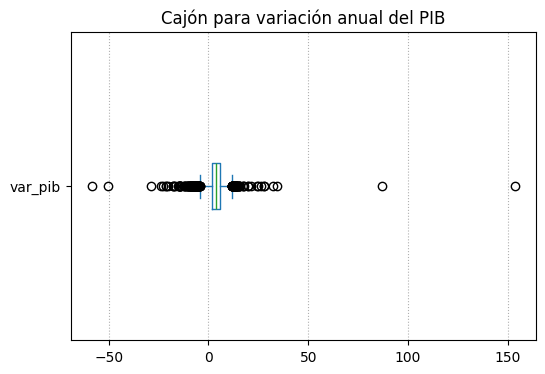

In [26]:
df_consolidado.plot(
    kind = "box",
    y = "var_pib",
    vert = False,
    figsize = [6,4],
    title = "Cajón para variación anual del PIB"
)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Dado que se observan valores atípicos que dificultan la visualización de la distribución, repite el gráfico excluyendo los mismos con el argumento `showfliers = False`.

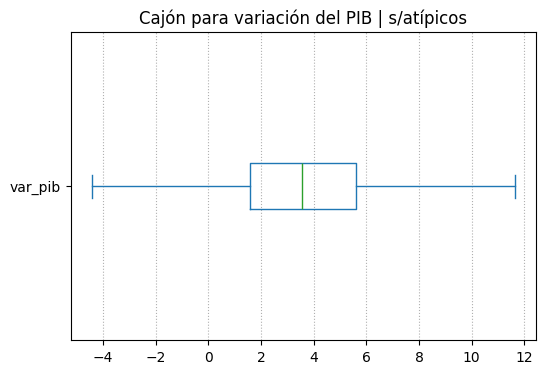

In [27]:
df_consolidado.plot(
    kind = "box",
    y = "var_pib",
    vert = False,
    figsize = [6,4],
    showfliers = False,
    title = "Cajón para variación del PIB | s/atípicos"
)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Vale señalar que un valor se considera atípico si el mismo NO se encuentra dentro del intervalo 

$$ \left[ Q_1 - 1.5R_Q,\; Q_3 + 1.5R_Q\right]$$

donde $Q_1$ es el primer cuartil, $Q_3$ el tercero, y $R_Q$ es el rango intercuartil definido por $R_Q = Q_3 - Q_1$.

Complementa ahora este resultado con un histograma tal que se cumpla con lo siguiente: 

* Excluye del dataset los casos atípicos.
* Utiliza en el gráfico un número de barras ($b$) pertinente, para lo cual puedes utilizar la fórmula $b \approx \sqrt{n}$, donde $n$ es el número de observaciones no atípicas.

Para esto utiliza el argumento `kind = "hist"`.

In [28]:
# Excluir valores atípicos
umbral_inf = df_consolidado["var_pib"].quantile(0.25) - 1.5 * (df_consolidado["var_pib"].quantile(0.75) - df_consolidado["var_pib"].quantile(0.25))
umbral_sup = df_consolidado["var_pib"].quantile(0.75) + 1.5 * (df_consolidado["var_pib"].quantile(0.75) - df_consolidado["var_pib"].quantile(0.25))
df_sin_atipicos = df_consolidado.query("var_pib >= @umbral_inf and var_pib <= @umbral_sup")
df_sin_atipicos.shape

(2962, 7)

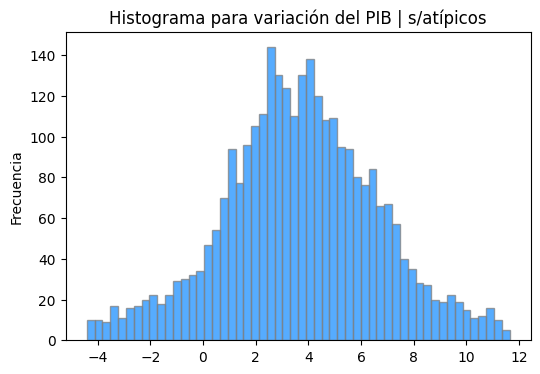

In [29]:
# Generar histograma
df_sin_atipicos.plot(
    kind = "hist",
    bins = int(np.sqrt(df_sin_atipicos.shape[0])),
    y = "var_pib",
    figsize = [6,4],
    legend = None,
    title = "Histograma para variación del PIB | s/atípicos",
    ylabel = "Frecuencia",
    edgecolor = "gray",
    color = "dodgerblue",
    alpha = 0.75
)
plt.show()

El histograma además puede resumirse en un diagrama de densidad. Créalo con el argumento `kind = "density"`.

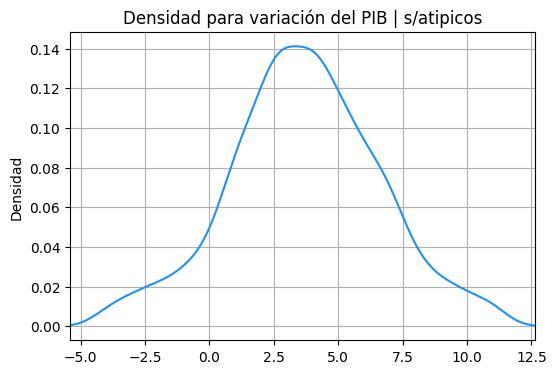

In [30]:
df_sin_atipicos.plot(
    kind = "density",
    y = "var_pib",
    figsize = [6,4],
    legend = None,
    title = "Densidad para variación del PIB | s/atipicos",
    color = "dodgerblue",
    grid = True,
    xlim = [df_sin_atipicos["var_pib"].min() - 1, df_sin_atipicos["var_pib"].max() + 1]
)
plt.ylabel("Densidad")
plt.show()

A modo de complemento, genera un gráfico con la evolución a través de los años de la variación en el PIB promedio mundial.

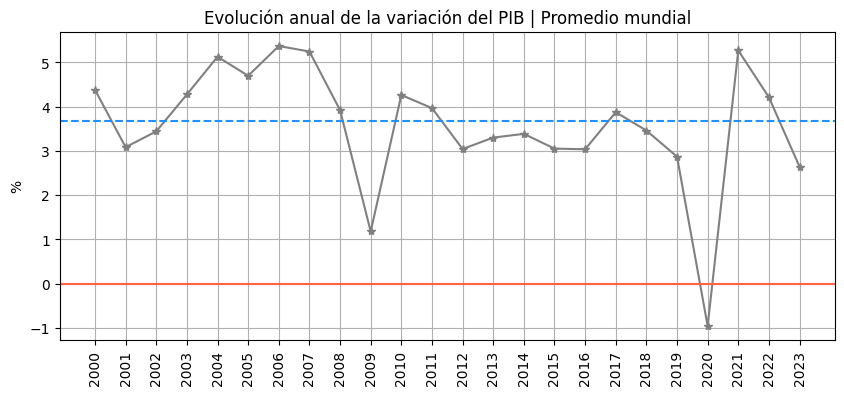

In [31]:
# Agregar datos
pib_anual = (
    df_sin_atipicos
    .groupby("year")
    .agg(var_pib = ("var_pib","mean"))
)

pib_anual.plot(
    figsize = [10,4],
    legend = None,
    marker = "*",
    xticks = range(2000,2024),
    rot = 90,
    grid = True,
    title = "Evolución anual de la variación del PIB | Promedio mundial",
    xlabel = "",
    ylabel = "%",
    color = "gray"
)
plt.axhline(y = 0, color = "tomato")
plt.axhline(y = df_sin_atipicos["var_pib"].mean(), color = "dodgerblue", linestyle = "--")
plt.show()

Extrae conclusiones relevantes respecto al comportamiento observado del indicador.

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | El promedio de variación del PIB para un país en un año cualquiera durante el nuevo siglo se ubica entre 3% y 4%, esto es, los estados han gozado en general de crecimiento y desarrollo económico. Sin embargo, se evidencia también una alta volatilidad producto seguramente a las realidades disímiles entre los países a nivel mundial. Al respecto se debe considerar que existen coyunturas socioeconómicas dispares así como factores exógenos (fenómenos naturales, entornos políticos, etc.) no previsibles que justifican los mencionados niveles de dispersión. |
| 2 | La crisis *subprime* del año 2009 conllevó un deterioro a nivel mundial en cuanto al crecimiento y desarrollo económico. En todo caso, lo expuesto no es siquiera comparable con los efectos derivados de la pandemia del COVID en el año 2020, en el cual hubo una contracción de más de 4 puntos porcentuales respecto al promedio histórico. |

### ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?

Antes de contestar esta pregunta, excluye del dataset los años 2009 y 2020 por ser especiales en cuanto a la situación mundial vivida durante esos períodos.

In [32]:
per_excluir = [2009,2020]
df_sin_atipicos = df_sin_atipicos.query("year != @per_excluir")

Estudia el grado de correlación existente entre las distintas métricas que tienes disponibles con el método `corr`. Visto que no conocemos si esta relación es lineal o no, incopora el argumento `method = "spearman"`, y recomiendo que investigues sobre este tipo de medida.

In [33]:
mat_corr = df_sin_atipicos[["var_pib","ahorro","var_pob","pct_urbana"]].corr(method = "spearman")
print(mat_corr.round(4))

            var_pib  ahorro  var_pob  pct_urbana
var_pib      1.0000  0.1327   0.1491     -0.2340
ahorro       0.1327  1.0000  -0.0364      0.2237
var_pob      0.1491 -0.0364   1.0000     -0.2706
pct_urbana  -0.2340  0.2237  -0.2706      1.0000


Recuerda que la correlación mide el grado de vinculación entre un par de variables, tal que:

* Si su valor es cercano a -1, se dice que ambas variables mantiene una relación **inversamente proporcional**, esto es, cuando una se incrementa la otra disminuye.
* Si su valor es cercano a +1, se dice que ambas variables mantiene una relación **directamente proporcional**, esto es, cuando una se incrementa la otra igualmente aumenta.
* Si su valor es cercano a 0, se dice que ambas variables no tienen relación estadística alguna.

Ante esto, repite el cálculo pero ahora utiliza los promedios anuales de cada indicador a fin de "diluir" los efectos exógenos de cada país evidenciados antes.

In [34]:
prom_anuales = df_sin_atipicos.groupby("year")[["var_pib","ahorro","var_pob","pct_urbana"]].mean()
mat_corr = prom_anuales[["var_pib","ahorro","var_pob","pct_urbana"]].corr(method = "spearman")
print(mat_corr.round(4))

            var_pib  ahorro  var_pob  pct_urbana
var_pib      1.0000  0.4557   0.2558     -0.4105
ahorro       0.4557  1.0000   0.0661      0.2355
var_pob      0.2558  0.0661   1.0000     -0.4884
pct_urbana  -0.4105  0.2355  -0.4884      1.0000


Visualiza la relación existente entre ahorro y var_pib mediante una gráfica de dispersión.

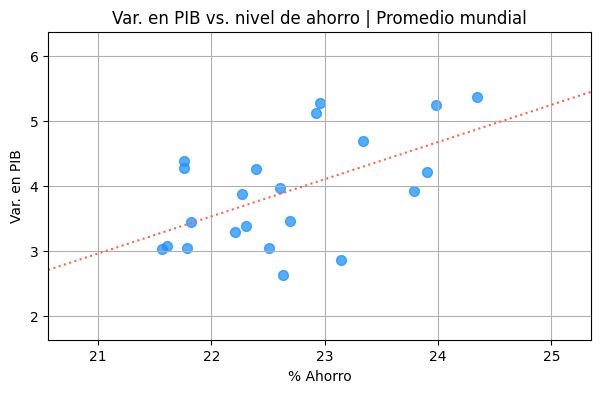

In [35]:
# Generar cruva de ajuste lineal simple
lin_fit = np.polyfit(
    x = prom_anuales["ahorro"], 
    y = prom_anuales["var_pib"], 
    deg = 1
)

# Generar gráfico de dispersion
prom_anuales.plot(
    kind = "scatter",
    x = "ahorro",
    y = "var_pib",
    figsize = [7,4],
    color = "dodgerblue",
    alpha = 0.75,
    grid = True,
    s = 50,
    title = "Var. en PIB vs. nivel de ahorro | Promedio mundial",
    xlabel = "% Ahorro",
    ylabel = "Var. en PIB",
    xlim = [prom_anuales["ahorro"].min() - 1, prom_anuales["ahorro"].max() + 1],
    ylim = [prom_anuales["var_pib"].min() - 1, prom_anuales["var_pib"].max() + 1]
)
plt.axline(xy1 = [0,lin_fit[1]], slope = lin_fit[0], color = "tomato", linestyle = ":")
plt.show()

Visualiza ahora la relación existente entre pct_urbana y var_pib mediante una gráfica de dispersión.

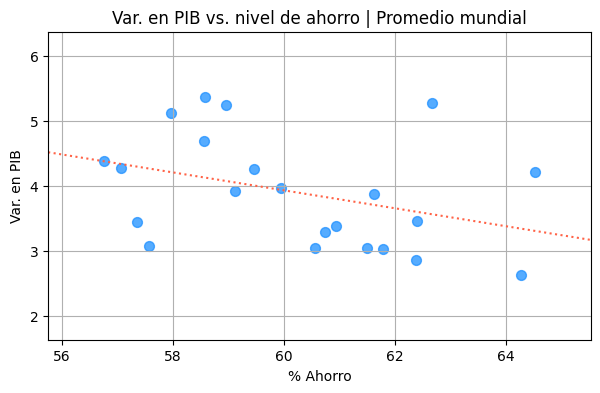

In [36]:
# Generar cruva de ajuste lineal simple
lin_fit = np.polyfit(
    x = prom_anuales["pct_urbana"], 
    y = prom_anuales["var_pib"], 
    deg = 1
)

# Generar gráfico de dispersion
prom_anuales.plot(
    kind = "scatter",
    x = "pct_urbana",
    y = "var_pib",
    figsize = [7,4],
    color = "dodgerblue",
    alpha = 0.75,
    grid = True,
    s = 50,
    title = "Var. en PIB vs. nivel de ahorro | Promedio mundial",
    xlabel = "% Ahorro",
    ylabel = "Var. en PIB",
    xlim = [prom_anuales["pct_urbana"].min() - 1, prom_anuales["pct_urbana"].max() + 1],
    ylim = [prom_anuales["var_pib"].min() - 1, prom_anuales["var_pib"].max() + 1]
)
plt.axline(xy1 = [0,lin_fit[1]], slope = lin_fit[0], color = "tomato", linestyle = ":")
plt.show()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Si bien a nivel de cada país no se evidencia que ningun indicador tiene una relación significativa con los cambios en el PIB (lo cual nuevamente estaría asociado al grado de volatilidad observado por las diversas condiciones socioeonómicas y factores exógenos de cada estado), a nivel promedio se podría afirmar que un mayor ahorro de la población conlleva mejores niveles de crecimiento económico producto de una mayor capacidad financiera para la generación de capital y consumo futuro. |
| 2 | En esta línea, en el promedio mundial se evidencia una relación negativa entre el porcentaje de población urbana y variación en el PIB, lo cual da cuenta posiblemente de mayores potenciales de desarrollo en estados con alta incidencia agrícola y extractiva. Lo anterior no sugiere que países con estas características sean más desarrollados que su contraparte, sino que los cambios observados a nivel de PIB son más grandes en términos porcentuales. |

### ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?

Crea una nueva columna en el dataset de tipo buleano de forma que se evidencien los casos en los que han existido recesiones. Para simplificar este concepto asumamos que una recesión es una variación negativa del PIB.

In [37]:
df_sin_atipicos["es_recesion"] = df_sin_atipicos["var_pib"].apply(lambda x: True if x < 0 else False)
df_sin_atipicos["es_recesion"].value_counts()

es_recesion
False    2587
True      199
Name: count, dtype: int64

Calcula en cuántos casos del dataset han existido recesiones y guarda este resultado en una variable llamada `casos_exitosos`.

In [38]:
casos_exitosos = df_sin_atipicos["es_recesion"].sum()
print(f"Observaciones en las que se han registrado recesiones: {casos_exitosos}")

Observaciones en las que se han registrado recesiones: 199


Guarda la totalidad de casos posibles en la variable `casos_totales`.

In [39]:
casos_totales = df_sin_atipicos["es_recesion"].count()
print(f"Observaciones totales: {casos_totales}")

Observaciones totales: 2786


Calcula la probabilidad de que en un año cualquiera un país entre en recesión. Recuerda que una probabilidad se mide como la razón entre los casos de éxito (eventos en los que sucede algo que estamos queriendo medir) y los casos totales observados. Además, una probabilidad debe cumplir 3 condiciones:

* Es positiva, es decir, todo evento *puede* suceder.
* Es estrictamente menor o igual a 1, es decir, potencialmente existen otros eventos *posibles*.
* La suma de todas las probabilidades de eventos posibles en un experimento es igual a 1, es decir, alguno *debe* suceder. 

In [40]:
prob_recesion = casos_exitosos / casos_totales
print(f"La probabilidad que un país entre en recesión en un año cualquiera es de: {prob_recesion:.1%}")

La probabilidad que un país entre en recesión en un año cualquiera es de: 7.1%


Vale que notes que esta probabilidad obtenida podría calcularse de forma directa con el siguiente código:

```py
prob_recesion = df_sin_atipicos["es_recesion"].mean()
```

Piensa el porqué esto funciona.

Para complementar este resultado, encuentra el top 10 de países con una mayor probabilidad de recesión. PAra esto, vuelve a repetir este cálculo agregando la información por pais.

In [41]:
# Obtener probabilidad de recesión por pais
rec_por_pais = (
    df_sin_atipicos
    .groupby("country_name")
    .agg(prob_recesion = ("es_recesion","mean"))
    .sort_values(by = "prob_recesion", ascending = False)
)

# Extraer 10 paises con mayor probabilidad
print(round(rec_por_pais.head(10) * 100,1))

                   prob_recesion
country_name                    
Libia                       46.2
Argentina                   38.1
Aruba                       33.3
Brunei Darussalam           31.8
Haiti                       28.6
Sudan                       25.0
Croacia                     23.8
Bahamas                     23.8
Paraguay                    22.7
Angola                      21.1


Identifica igualmente el porcentaje de paises que han presentado recesiones en este periodo de tiempo.

In [42]:
# Contar paises con recesion
paises_con_recesion = len(rec_por_pais.query("prob_recesion > 0"))

# Contar total de paises
paises_totales = len(rec_por_pais)
print(f"Porcentaje de paises con alguna recesion: {paises_con_recesion / paises_totales:.1%}")

Porcentaje de paises con alguna recesion: 58.0%


**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | En promedio, un año malo en términos económicos para un país cualquiera puede presentarse aproximadamente una vez por cada 12 años. En consecuencia se pueden esperar ciclos de alrededor de 10 a 11 años de crecimiento sostenido en las economías nacionales, ante lo cual las políticas de desarrollo e inversión pública y privada deberían alinearse a esta realidad observada para así garantizar que las variaciones positivas en el PIB sean las máximas posibles en estos años. |
| 2 | Entre los 10 países con mayor probabilidad de recesión resaltan, aquellos en donde han existido situación graves en términos economícos, sociales o políticos. Por ejemplo en Libia existe una grave crisis humanitaria desde el año 2011, en Argentina se han presentado períodos de deterioro económico especialmente a principios de la década del 2000. Lo expusto ratifica lo mencionado en cuanto al impacto de factores externos en la variación del PIB. |
| 3 | Las recesiones en este siglo son un escenario bastante común, lo anterior queda evidenciado en el hecho que casi un 60% de los países las han tenido. Es recomendable por tanto, que el Banco Mundial amplíe su expectro de apoyo a países exigiendo como garantías el cumplimiento de políticas de desarrollo. |

### ¿Existen diferencias en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

Escoge 10 países que personalmente consideres de bajo desarrollo (i.e Ecuador, Bolivia, Guatemala, etc.), y 10 que consideres de alto desarrollo (i.e Estados Unidos, Alemania, Japón, etc.). Filtra el dataset de forma que solamente conserves estos países y adiciona una nueva columna que distinga a los dos grupos.  

In [43]:
# Seleccionar paises de alto y bajo desarrollo
bajo_desarrollo = ["Ecuador", "Bolivia", "Guatemala", "Madagascar", "Nepal", "Niger", "Nicaragua", "Burundi", "Mali", "Haiti"]
alto_desarrollo = ["Estados Unidos", "Alemania", "Japon", "Francia", "Canada", "Noruega", "Australia", "Singapur", "Dinamarca", "Suiza"]
paises_seleccionados = alto_desarrollo.copy()
paises_seleccionados.extend(bajo_desarrollo)

# Filtrar dataset con paises seleccionados
df_filtrado = df_sin_atipicos.query("country_name in @paises_seleccionados")

# Adicionar columna con grupos de paises
df_filtrado["nivel_desarrollo"] = df_filtrado["country_name"].apply(lambda x: "Alto" if x in alto_desarrollo else "Bajo")
df_filtrado[["nivel_desarrollo","country_name"]].value_counts().reset_index().sort_values(by = "nivel_desarrollo")

,nivel_desarrollo,country_name,count
0,Alto,Australia,22
3,Alto,Canada,22
4,Alto,Suiza,22
5,Alto,Alemania,22
6,Alto,Dinamarca,22
8,Alto,Francia,22
10,Alto,Japon,22
12,Alto,Noruega,22
14,Alto,Estados Unidos,22
19,Alto,Singapur,21


Estudia comparativamente la distribución de var_pib en los países de alto y bajo desarrollo.

In [44]:
# Extraer muestra de valores de paises de alto desarrollo
vpib_alto = df_filtrado.query("nivel_desarrollo == 'Alto'")["var_pib"]
vpib_bajo = df_filtrado.query("nivel_desarrollo == 'Bajo'")["var_pib"]

# Calcular la media para ambos grupos
res_estadistico = pd.concat([vpib_alto.describe(),vpib_bajo.describe()], axis = 1)
res_estadistico.columns = ["Alto","Bajo"]
print(res_estadistico.round(2))

         Alto    Bajo
count  219.00  216.00
mean     2.40    3.80
std      1.77    2.47
min     -1.22   -3.90
25%      1.17    2.51
50%      2.21    4.10
75%      3.06    5.21
max      9.94   10.55


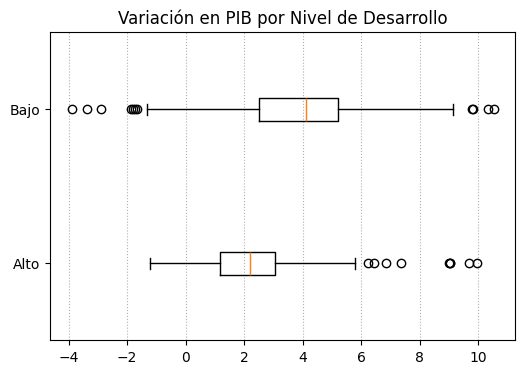

In [45]:
# Visualizar distribuciones con cajones
plt.figure(figsize = [6,4])
plt.boxplot([vpib_alto,vpib_bajo], vert = False)
plt.yticks(ticks = [1,2], labels = ["Alto","Bajo"])
plt.grid(axis = "x", linestyle = ":")
plt.title("Variación en PIB por Nivel de Desarrollo")
plt.show()

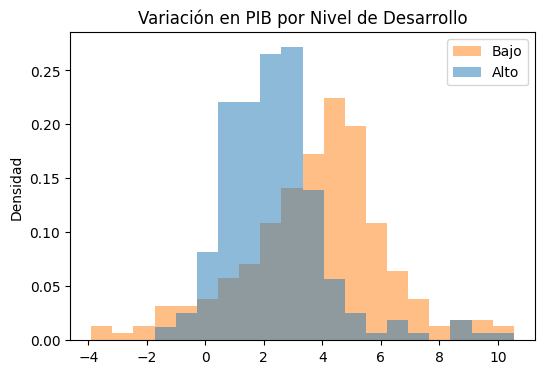

In [46]:
# Visualizar distribuciones con histogramas
plt.figure(figsize = [6,4])
plt.hist(
    [vpib_alto,vpib_bajo], 
    bins = 20, 
    density = True, 
    histtype = "stepfilled", 
    alpha = 0.5
)
plt.title("Variación en PIB por Nivel de Desarrollo")
plt.ylabel("Densidad")
plt.legend(["Bajo","Alto"])
plt.show()

Los resultados aquí alcanzados parecerían indicar que en promedio la variación del PIB en países de bajo desarrollo es mayor a aquella de los países de alto desarrollo. 

¿Cómo podemos estar completamente seguros de esta afirmación? La respuesta radica en la **Inferencia estadística**, cuyas técnicas nos permiten verificar hipótesis de forma objetiva y robusta.

Define por tanto tu hipótesis especificando su componente nulo y alternativo. En general, la hipótesis nula hace referencia a aquel postulando que indica que no existen efectos, mientras que la alternativa hace mención al postulado donde sí se darían efectos. 

**DEFINICIÓN DE LA HIPÓTESIS NULA Y ALTERNATIVA**

| Hipótesis | Postulado |
| ---- | ---- |
| Nula |  La variación del PIB promedio en países de bajo desarrollo es IGUAL a la variación promedio en países de alto desarrollo. |
| Alternativa | La variación del PIB promedio en países de bajo desarrollo es MAYOR a la variación promedio en países de alto desarrollo. |

Dado que nuestra hipótesis involucra a la **media** como estadístico, debemos utilizar técnicas de inferencia justamente enfocadas en este estadístico. Aquí algunas opciones populares:

* *Prueba Z*: Asume que las distribuciones del estadístico (media) sigue una distribución Normal y que las varianzas poblacionales de los datos son conocidas. 
* *Prueba T*: Asume que las distribuciones del estadístico sigue una distribución aproximadamente Normal y que las varianzas poblacionales de los datos son desconocidas.
* *Prueba U* de Mann-Whitney: No asume nada asociado a las distribuciones del estadístico y es espacialmente útil cuando el número de observaciones es bajo.

En vista que no estamos seguros si en efecto las medias objeto de análisis siguen una distribución normal, aunque por los resultados alcanzados hasta ahora intuimos que aproximadamente sí lo hacen, aplica una *prueba T* para validar la hipótesis planteada mediante la función `ttest_ind` de la librería **Scipy**. 

In [47]:
prueba_t = st.ttest_ind(
    vpib_bajo, 
    vpib_alto, 
    equal_var = False, # Este argumento se deduce al observar el resumen estadistico previo
    alternative = "greater" # Este argumento hace referencia al tipo de hipótesis alternativa realizado
)
print(prueba_t)

TtestResult(statistic=np.float64(6.7814848710244195), pvalue=np.float64(2.214483340524737e-11), df=np.float64(389.45774067704065))


Toda prueba de hipótesis entrega como resultado un *valor p* que mide la probabilidad teórica de repetir este experimento (extraer muestras de países de alto y bajo desarollo de manera aleatoria y contrastar sus medias), y obtener resultados que ratifiquen la hipótesis nula, es decir, encontrar que las variaciones del PIB son iguales entre ambos grupos.

Ante esta definición, no convendría descartar nuestra Hipótesis Nula si este *valor p* es significativo, digamos mayor a 5%. Pero sí la descartaríamos a favor de la Hipótesis Alternativa en caso contrario.

Ejecuta por tanto esta validación y por consiguiente verificando la afirmación especificada líneas arriba. Puedes extraer el valor p mediante al atributo `pvalue`. 

In [48]:
valor_p = prueba_t.pvalue

if valor_p <= 0.05:
    resultado = "MAYOR"
else:
    resultado = "IGUAL"

print(f"Valor p: {valor_p:.4%}\nLos países de bajo desarrollo tendrían {resultado} variación media del PIB con respecto a los paises de alto desarrollo.")

Valor p: 0.0000%
Los países de bajo desarrollo tendrían MAYOR variación media del PIB con respecto a los paises de alto desarrollo.


Con el propósito de ratificar este resultado, realiza una prueba U de Mann-Whitney mediante la función `mannwhitneyu` de **Scipy**.

In [49]:
# Ejecutar la prueba
prueba_mw = st.mannwhitneyu(
    vpib_bajo, 
    vpib_alto,
    alternative = "greater"
)

# Decidir en base a valor p
valor_p = prueba_mw.pvalue

if valor_p <= 0.05:
    resultado = "MAYOR"
else:
    resultado = "IGUAL"

print(f"Valor p: {valor_p:.4%}\nLos países de bajo desarrollo tendrían {resultado} variación media del PIB con respecto a los paises de alto desarrollo.")

Valor p: 0.0000%
Los países de bajo desarrollo tendrían MAYOR variación media del PIB con respecto a los paises de alto desarrollo.


**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Los países de bajo desarrollo tienden a crecer porcentualmente más que los países más desarrollados. Esto en principio podría resultar contraintuitivo pero se explica por el hecho que incrementar 1 punto porcentual de una base menor es, por decirlo de alguna manera, "más sencillo" que hacerlo de una base mayor. Aquí un ejemplo puramente ilustrativo: *Sea USD100 M el PIB de un país de bajo desarrollo en un año cualquiera, y USD1,000 M el de un pais de alto desarrollo. Incrementar 1% para el primer caso implica una variación absoluta de apenas USD1 millón, mientras que para el segundo sería USD10 millones. ¡Mucho más!* |

    

Como has podido evidenciar, saber estadística te ayudará mucho en tu camino como analista o científico de datos. Te recomiendo por tanto que escuches este playlist sobre [Fundamentos de Estadística](https://youtube.com/playlist?list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9&si=fTrXd4SYsSvR_iVe) creado por el canal *StatQuest de Josh Starmer*.